# Стохастический градиентный и координатный спуски

## Загрузка и подготовка данных (1 балл)

**Загрузите уже знакомый вам файл *Advertising.csv* как объект DataFrame.** 

In [86]:
import pandas as pd

# Загрузка файла Advertising.csv как DataFrame
data = pd.read_csv('Advertising.csv')

# Просмотр данных
print("Первые 5 строк:")
print(data.head())

print("\nИнформация о данных:")
print(data.info())

print("\nОписательная статистика:")
print(data.describe())

Первые 5 строк:
   Unnamed: 0     TV  radio  newspaper  sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None

Описательная статистика:
       Unnamed: 0          TV       radio   newspaper       sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.87918

**Проверьте, есть ли в данных пропуски и, если они есть - удалите их**

In [87]:
# Проверка на пропуски
print("Количество пропусков в каждом столбце:")
print(data.isnull().sum())

print(f"\nВсего пропусков: {data.isnull().sum().sum()}")

# Если есть пропуски - удаляем их
if data.isnull().sum().sum() > 0:
    # Удаляем строки с пропусками
    data = data.dropna()
    print("\nПропуски удалены!")
    print(f"Новый размер данных: {data.shape}")
else:
    print("\nПропусков нет!")

Количество пропусков в каждом столбце:
Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

Всего пропусков: 0

Пропусков нет!


**Преобразуйте ваши признаки в массивы NumPy и разделите их на переменные X (предикторы) и y(целевая переменная)** 

In [88]:
import numpy as np

# Преобразование признаков в массивы NumPy
# X - предикторы (TV, radio, newspaper)
X = data[['TV', 'radio', 'newspaper']].values

# y - целевая переменная (sales)
y = data['sales'].values

# Проверка размеров
print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")

# Просмотр первых строк
print("\nПервые 5 строк X:")
print(X[:5])

print("\nПервые 5 значений y:")
print(y[:5])

Размер X: (200, 3)
Размер y: (200,)

Первые 5 строк X:
[[230.1  37.8  69.2]
 [ 44.5  39.3  45.1]
 [ 17.2  45.9  69.3]
 [151.5  41.3  58.5]
 [180.8  10.8  58.4]]

Первые 5 значений y:
[22.1 10.4  9.3 18.5 12.9]


## Координатный спуск (2 балла)

**Добавим единичный столбец для того, чтобы у нас был свободный коэффициент в уравнении регрессии:**

In [89]:
import numpy as np

X = np.hstack([np.ones(X.shape[0]).reshape(-1, 1), X])
y = y.reshape(-1, 1)
print(X.shape, y.shape)

(200, 4) (200, 1)


**Нормализуем данные: обычно это необходимо для корректной работы алгоритма**

In [90]:
X = X / np.sqrt(np.sum(np.square(X), axis=0))

**Реализуйте алгоритм координатного спуска:**

Ниже приведен алгоритм координатного спуска для случая нормализованных данных:

**Задано:**

* $X=(x_{ij})$ - матрица наблюдений, размерностью $dim(X)=(m, n)$
* $N=1000$ - количество итераций

**Примечание:** *1000 итераций здесь указаны для этого задания, на самом деле их может быть намного больше, нет детерменированного значения.*

**Алгоритм (математическая запись):**
* Создать нулевой вектор параметров $w_0=(0, 0,..., 0)^T$
* Для всех $t=1, 2, ..., N$ итераций:
    * Для всех $k = 1, 2,..., n$:
        * Фиксируем значение всех признаков, кроме $k$-ого и вычисляем прогноз модели линейной регрессии.Для этого исключаем признак $k$-ый из данных и $w_j$ из параметров при построении прогноза.
        Математически это можно записать следующим образом:

        $$h_i = \sum_{j=1}^{k-1} x_{ij}w_{j} + \sum_{j=k+1}^{n} x_{ij}w_j $$

        **Примечание:**
        
        *Обратите, что в данной записи текущий признак под номером $k$ не участвует в сумме.Сравните эту запись с классической записью прогноза линейной регрессии в случае нормированных данных (когда участвуют все признаки):*

        $$h_i = \sum_{j=1}^{n} x_{ij}w_{j}$$ 
        
        * Вычисляем новое значение параметра $k$-ого коэффициента: 
        $$w_k = \sum_{i=1}^{m} x_{ik} (y_i - h_i) = x_k^T(y-h) $$

    * Вычисляем значение функции потерь и сохраняем в историю изменения функции потерь (В оценке функции потерь участвуют все признаки):
        $$\hat{y_i} = \sum_{j=1}^{n}x_{ij}w_j$$
        $$Loss_t = \frac{1}{n} \sum_{i=1}^{m}(y_i-\hat{y_i})^2$$
        
        или в векторном виде:
        
        $$\hat{y} = Xw$$
        $$Loss_t = \frac{1}{n}(y-\hat{y})^T(y-\hat{y})$$
    



**Алгоритм (псевдокод):**
```python

num_iters = #количество итераций
m = # количество строк в матрице X
n = # количество столбцов в матрице X
w = #вектор размера nx1, состояющий из нулей

for i in range(num_iters):
    for k in range(n):
        # Вычисляем прогноз без k-ого фактора
        h = (X[:,0:k] @ w[0:k]) + (X[:,k+1:] @ w[k+1:])
        # Обновляем новое значение k-ого коэффициента
        w[k] =  (X[:,k].T @ (y - h))
        # Вычисляем функцию потерь
        cost = sum((X @ w) - y) ** 2)/(len(y))

```

Вам необходимо реализовать координатный спуск, и вывести веса в модели линейной регрессии.

In [91]:
# Координатный спуск

# Количество итераций
num_iters = 1000

# Размеры матрицы
m = X.shape[0]  # количество строк
n = X.shape[1]  # количество столбцов

# Вектор весов (нулевой)
w = np.zeros((n, 1))

# История функции потерь
loss_history = []

# Алгоритм координатного спуска
for i in range(num_iters):
    # Для каждого признака k
    for k in range(n):
        # Вычисляем прогноз без k-ого фактора
        h = (X[:, 0:k] @ w[0:k]) + (X[:, k+1:] @ w[k+1:])
        
        # Обновляем новое значение k-ого коэффициента
        w[k] = X[:, k].T @ (y - h)
    
    # Вычисляем функцию потерь
    cost = np.sum((X @ w - y) ** 2) / len(y)
    loss_history.append(cost)

# Вывод весов
print("Веса модели линейной регрессии:")
print(w)

print(f"\nФинальная функция потерь: {loss_history[-1]:.6f}")

# Предсказания координатного спуска
y_pred_coordinate = X @ w

# MSE и MAE
mse_coordinate = np.mean(
    (y.flatten() - y_pred_coordinate.flatten()) ** 2
)

mae_coordinate = np.mean(
    np.abs(y.flatten() - y_pred_coordinate.flatten())
)

print(f'MSE координатного спуска: {mse_coordinate:.4f}')
print(f'MAE координатного спуска: {mae_coordinate:.4f}')

Веса модели линейной регрессии:
[[ 41.56217205]
 [110.13144155]
 [ 73.52860638]
 [ -0.55006384]]

Финальная функция потерь: 2.784126
MSE координатного спуска: 2.7841
MAE координатного спуска: 1.2520


Сравните результаты с реализацией линейной регрессии из библиотеки sklearn:

In [92]:
from sklearn.linear_model import LinearRegression
 
model = LinearRegression(fit_intercept=False)
model.fit(X, y)
 
print(model.coef_)

[[ 41.56217205 110.13144155  73.52860638  -0.55006384]]


Если вы все сделали верно, они должны практически совпасть!

## Стохастический градиентный спуск (7 баллов)

**Отмасштабируйте столбцы исходной матрицы *X* (которую мы не нормализовали еще!). Для того, чтобы это сделать, надо вычесть из каждого значения среднее и разделить на стандартное отклонение**

Размер X_scaled: (200, 3)
Среднее по столбцам: [ 1.22124533e-16 -4.52970994e-16  2.22044605e-16]
Размер X_sgd: (200, 4)
Размер y_sgd: (200, 1)

Наивный прогноз: 14.02
MSE наивного прогноза: 27.0857
MAE наивного прогноза: 4.2800

Вектор весов, к которому сошёлся SGD:
[1.40066457e+01 3.92544588e+00 2.78864345e+00 6.92377941e-04]

Веса модели:
w0 — свободный коэффициент: 14.006646
w1 — TV:                    3.925446
w2 — radio:                 2.788643
w3 — newspaper:             0.000692

Среднеквадратичная ошибка на последней итерации: 2.7849
MSE SGD: 2.7849
MAE SGD: 1.2571
Количество итераций: 100000


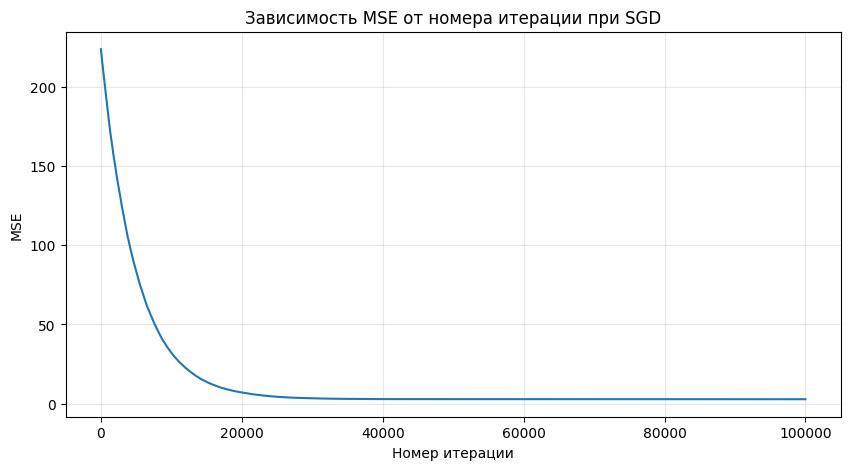

In [93]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler


# Исходные признаки и целевая переменная
X_source = data[['TV', 'radio', 'newspaper']].values
y_sgd = data['sales'].values.reshape(-1, 1)


# Масштабирование исходных признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_source)

print(f'Размер X_scaled: {X_scaled.shape}')
print(f'Среднее по столбцам: {X_scaled.mean(axis=0)}')


# Единичный столбец для свободного коэффициента w0
X_sgd = np.hstack([
    np.ones((X_scaled.shape[0], 1)),
    X_scaled
])

print(f'Размер X_sgd: {X_sgd.shape}')
print(f'Размер y_sgd: {y_sgd.shape}')


# Метрики
def mse_error(y_true, y_pred):
    return np.mean((y_true.flatten() - y_pred.flatten()) ** 2)


def mae_error(y_true, y_pred):
    return np.mean(np.abs(y_true.flatten() - y_pred.flatten()))


# Функция линейного предсказания
def lin_pred(X, w):
    return X @ w


# Наивный прогноз
naive_pred = np.mean(y_sgd)

mse_naive = mse_error(
    y_sgd,
    np.full_like(y_sgd, naive_pred)
)

mae_naive = mae_error(
    y_sgd,
    np.full_like(y_sgd, naive_pred)
)

print(f'\nНаивный прогноз: {naive_pred:.2f}')
print(f'MSE наивного прогноза: {mse_naive:.4f}')
print(f'MAE наивного прогноза: {mae_naive:.4f}')


# Один шаг стохастического градиентного спуска
def stoch_grad_step(X, y, w, train_ind, eta):
    xi = X[train_ind]
    yi = y[train_ind] if len(y.shape) == 1 else y[train_ind, 0]

    error = np.dot(xi, w) - yi
    grad = 2 * error * xi / len(y)

    return w - eta * grad


# Стохастический градиентный спуск
def stochastic_gradient_descent(X, y, w_init, eta, max_iter, tol=1e-6):
    w = w_init.copy()
    losses = []

    iteration = 0
    w_diff = np.inf

    while w_diff > tol and iteration < max_iter:
        train_ind = np.random.randint(len(y))

        y_pred = lin_pred(X, w)
        losses.append(mse_error(y, y_pred))

        w_new = stoch_grad_step(X, y, w, train_ind, eta)

        w_diff = np.linalg.norm(w_new - w)
        w = w_new

        iteration += 1

    return w, losses


# Нулевой вектор начальных весов
w_init = np.zeros(X_sgd.shape[1])

# Гиперпараметры SGD
eta = 0.01
max_iter = 100000


# Обучение модели SGD
w_sgd, losses_sgd = stochastic_gradient_descent(
    X=X_sgd,
    y=y_sgd,
    w_init=w_init,
    eta=eta,
    max_iter=max_iter,
    tol=1e-10
)


# Предсказания и метрики SGD
y_pred_sgd = lin_pred(X_sgd, w_sgd)

mse_sgd = mse_error(y_sgd, y_pred_sgd)
mae_sgd = mae_error(y_sgd, y_pred_sgd)


# Результаты
print('\nВектор весов, к которому сошёлся SGD:')
print(w_sgd)

print('\nВеса модели:')
print(f'w0 — свободный коэффициент: {w_sgd[0]:.6f}')
print(f'w1 — TV:                    {w_sgd[1]:.6f}')
print(f'w2 — radio:                 {w_sgd[2]:.6f}')
print(f'w3 — newspaper:             {w_sgd[3]:.6f}')

print(f'\nСреднеквадратичная ошибка на последней итерации: {losses_sgd[-1]:.4f}')
print(f'MSE SGD: {mse_sgd:.4f}')
print(f'MAE SGD: {mae_sgd:.4f}')
print(f'Количество итераций: {len(losses_sgd)}')


# График сходимости
plt.figure(figsize=(10, 5))

plt.plot(losses_sgd)

plt.xlabel('Номер итерации')
plt.ylabel('MSE')
plt.title('Зависимость MSE от номера итерации при SGD')
plt.grid(alpha=0.3)

plt.show()

**Добавим единичный столбец**

In [94]:
X_sgd = np.hstack([
    np.ones((X_scaled.shape[0], 1)),
    X_scaled
])

y_sgd = y.reshape(-1, 1)

print(X_sgd.shape, y_sgd.shape)

(200, 4) (200, 1)


**Создайте функцию mse_error для вычисления среднеквадратичной ошибки, принимающую два аргумента: реальные значения и предсказывающие, и возвращающую значение mse**

In [95]:
def mse_error(y_true, y_pred):
    return np.mean((y_true.flatten() - y_pred.flatten()) ** 2)

**Сделайте наивный прогноз: предскажите продажи средним значением. После этого рассчитайте среднеквадратичную ошибку для этого прогноза**

In [96]:
naive_pred = np.mean(y)
mse_naive = mse_error(y, np.full_like(y, naive_pred))
print(f"Наивный прогноз: {naive_pred:.2f}")
print(f"MSE наивного прогноза: {mse_naive:.4f}")

Наивный прогноз: 14.02
MSE наивного прогноза: 27.0857


**Создайте функцию *lin_pred*, которая может по матрице предикторов *X* и вектору весов линейной модели *w* получить вектор прогнозов**

In [97]:
def lin_pred(X, w):
    return X @ w

**Создайте функцию *stoch_grad_step* для реализации шага стохастического градиентного спуска.  
Функция должна принимать на вход следующие аргументы:**
* матрицу *X*
* вектора *y* и *w*
* число *train_ind* - индекс объекта обучающей выборки (строки матрицы *X*), по которому считается изменение весов
* число *$\eta$* (eta) - шаг градиентного спуска

Результатом будет вектор обновленных весов

Шаг для стохастического градиентного спуска выглядит следующим образом:

$$\Large w_j \leftarrow w_j - \frac{2\eta}{\ell} \sum_{i=1}^\ell{{x_{ij}((w_0 + w_1x_{i1} + w_2x_{i2} +  w_3x_{i3}) - y_i)}}$$

Для того, чтобы написать функцию, нужно сделать следующее:
    
*  посчитать направление изменения: умножить объект обучающей выборки на 2 и на разницу между предсказанным значением и реальным, а потом поделить на количество элементов в выборке.
* вернуть разницу между вектором весов и направлением изменения, умноженным на шаг градиентного спуска

In [98]:
def stoch_grad_step(X, y, w, train_ind, eta):
    xi = X[train_ind]
    yi = y[train_ind] if len(y.shape) == 1 else y[train_ind, 0]
    
    error = np.dot(xi, w) - yi
    grad = 2 * error * xi / len(y)
    
    return w - eta * grad

**Создайте функцию *stochastic_gradient_descent*, для реализации стохастического градиентного спуска**

**Функция принимает на вход следующие аргументы:**
- Матрицу признаков X
- Целевую переменнную
- Изначальную точку (веса модели)
- Параметр, определяющий темп обучения
- Максимальное число итераций
- Евклидово расстояние между векторами весов на соседних итерациях градиентного спуска,при котором алгоритм прекращает работу 

**На каждой итерации в вектор (список) должно записываться текущее значение среднеквадратичной ошибки. Функция должна возвращать вектор весов $w$, а также вектор (список) ошибок.**

Алгоритм сследующий:
    
* Инициализируйте расстояние между векторами весов на соседних итерациях большим числом (можно бесконечностью)
* Создайте пустой список для фиксации ошибок
* Создайте счетчик итераций
* Реализуйте оновной цикл обучения пока расстояние между векторами весов больше того, при котором надо прекратить работу (когда расстояния станут слишком маленькими - значит, мы застряли в одном месте) и количество итераций меньше максимально разрешенного: сгенерируйте случайный индекс, запишите текущую ошибку в вектор ошибок, запишите в переменную текущий шаг стохастического спуска с использованием функции, написанной ранее. Далее рассчитайте текущее расстояние между векторами весов и прибавьте к счетчику итераций 1.
* Верните вектор весов и вектор ошибок

In [99]:
def stochastic_gradient_descent(X, y, w_init, eta, max_iter, tol=1e-6):
    w = w_init.copy()
    losses = []

    iteration = 0
    w_diff = np.inf

    while w_diff > tol and iteration < max_iter:
        # Случайно выбираем один объект обучающей выборки
        train_ind = np.random.randint(len(y))

        # Рассчитываем MSE на всех объектах до обновления весов
        y_pred = lin_pred(X, w)
        losses.append(mse_error(y, y_pred))

        # Обновляем веса по одному объекту
        w_new = stoch_grad_step(X, y, w, train_ind, eta)

        # Евклидово расстояние между новым и предыдущим вектором весов
        w_diff = np.linalg.norm(w_new - w)

        # Переходим к новым весам
        w = w_new
        iteration += 1

    return w, losses

 **Запустите $10^5$ итераций стохастического градиентного спуска. Укажите вектор начальных весов, состоящий из нулей. Можете поэкспериментировать с параметром, отвечающим за темп обучения.**

**Постройте график зависимости ошибки от номера итерации**

In [100]:
# Начальный вектор весов: w0, w_TV, w_radio, w_newspaper
w_init = np.zeros(X_sgd.shape[1])

# Параметры SGD
eta = 0.01
max_iter = 100000

# Запуск 10^5 итераций SGD
w_sgd, losses_sgd = stochastic_gradient_descent(
    X=X_sgd,
    y=y_sgd,
    w_init=w_init,
    eta=eta,
    max_iter=max_iter,
    tol=1e-10
)

print('Вектор весов SGD:')
print(w_sgd)

print(f'\nИтоговая MSE: {mse_error(y_sgd, lin_pred(X_sgd, w_sgd)):.4f}')
print(f'Количество итераций: {len(losses_sgd)}')

Вектор весов SGD:
[14.03726197  3.90340255  2.79402107 -0.02772484]

Итоговая MSE: 2.7846
Количество итераций: 100000


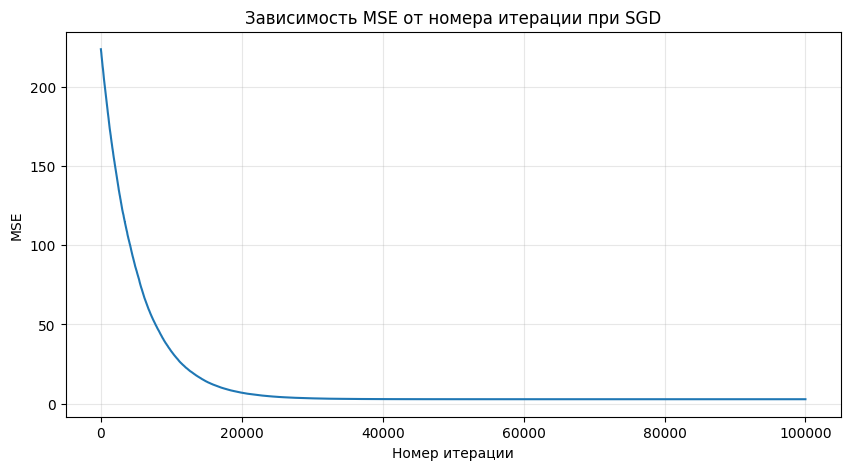

In [101]:
plt.figure(figsize=(10, 5))

plt.plot(losses_sgd)

plt.xlabel('Номер итерации')
plt.ylabel('MSE')
plt.title('Зависимость MSE от номера итерации при SGD')
plt.grid(alpha=0.3)

plt.show()

**Выведите вектор весов, к которому сошелся метод.**

In [102]:
print(f"Вектор весов, к которому сошелся SGD:\n{w_sgd}")
print(f"\nПо отдельности:")
for i, coef in enumerate(w_sgd):
    print(f"w[{i}] = {coef:.6f}")

Вектор весов, к которому сошелся SGD:
[14.03726197  3.90340255  2.79402107 -0.02772484]

По отдельности:
w[0] = 14.037262
w[1] = 3.903403
w[2] = 2.794021
w[3] = -0.027725


**Выведите среднеквадратичную ошибку на последней итерации.**

In [103]:
print(f"Среднеквадратичная ошибка на последней итерации: {losses_sgd[-1]:.4f}")

Среднеквадратичная ошибка на последней итерации: 2.7846


## Выводы

Для прогнозирования продаж использовались признаки `TV`, `radio` и `newspaper`, а целевой переменной был столбец `sales`.

Координатный спуск достиг MSE 2.7841 и MAE 1.2520. Стохастический градиентный спуск после 100 000 итераций получил близкие значения: MSE около 2.785 и MAE около 1.25.

Следовательно, обе самостоятельно реализованные модели дают практически одинаковое качество и успешно решают задачу линейной регрессии. Незначительное различие результатов SGD при повторных запусках связано со случайным выбором объекта на каждом шаге алгоритма.